Empresa de marketing

In [ ]:
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

Casi nunca se trabajan los archivos de esta manera, uno no sube el archivo sino un proceso. No se deben encontrar datos en el repositorio.

In [ ]:
df = pd.read_csv('/content/base_datos_restaurantes_USA_v2.csv')
df.head()

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350


1. Descarga de Datos
2. EDA: parte anterior al ejercicio que ayuda a hacer hipotesis y empezar a crear el modelo base (da indicios de variables redundantes, relaciones entre variables, posibles asociaciones)

In [ ]:
pd.options.display.max_columns =  None
pd.options.display.max_rows = None

Descripción de columnas

* id_persona: Identificador único de la persona.
* nombre: Nombre de pila de la persona.
* apellido: Apellido de la persona.
* edad: Edad de la persona en años.
* genero: Género declarado de la persona (Femenino o Masculino)
* ciudad_residencia: Ciudad donde reside actualmente la persona (elegida entre 10 ciudades principales de EE. UU.)
* estrato_socioeconomico: Nivel socioeconómico aproximado (Bajo, Medio, Alto, Muy Alto).
* frecuencia_visita: Número aproximado de visitas al mes a restaurantes.
* promedio_gasto_comida: Gasto promedio por visita a restaurantes (USD).
* ocio: Indica si la persona suele participar en actividades de ocio (Sí / No).
* consume_licor: Indica si la persona suele consumir licor (Sí / No) al visitar un restaurante.
* preferencias_alimenticias: Preferencia de dieta (Vegano, Vegetariano, Pesacado, Mariscos, etc.).
* membresia_premium: Indica si la persona tiene membresía premium (Sí / No) en algún restaurante.
* telefono_contacto: Número de teléfono (campo innecesario para el análisis, sirve para practicar limpieza).
* correo_electronico: Correo electrónico de la persona.
* tipo_de_pago_mas_usado: Método de pago más frecuente (Efectivo, Tarjeta, App, Cripto).
* ingresos_mensuales: Ingresos mensuales estimados (USD).

Se van a explorar todas las variables

Identificar los tipos de dato, el porcentaje de valores nulos, valores duplicados, ruido y tipos.

Describir estadisticamente las variables.

In [ ]:
df.head(20)

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350
5,1291749568,Donna,Davis,26.0,Femenino,Dallas,Alto,6,52.47,No,Sí,Carnes,Sí,976.606.6259x578,daniel28@example.com,Efectivo,8545
6,3592027247,Jason,Mcpherson,80.0,Masculino,NYC,Muy Alto,10,56.11,No,No,Vegano,Sí,001-327-542-1940x4789,bcastillo@example.org,Efectivo,10120
7,8373803828,Julie,Russo,66.0,Femenino,Boston,Muy Alto,9,19.94,No,Sí,Vegetariano,Sí,NaN,NaN,Efectivo,13456
8,7395628831,Mark,Hall,31.0,Masculino,NYC,Medio,5,16.17,No,Sí,Vegetariano,No,NaN,kara70@example.com,App,3350
9,5394273061,Sara,Ball,37.0,Femenino,Boston,Bajo,1,11.35,Sí,No,Carnes,No,563-346-4749x6591,smithstacy@example.com,Efectivo,1197


In [ ]:
df.shape

(30000, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 30000 non-null  int64  
 1   nombre                     30000 non-null  object 
 2   apellido                   30000 non-null  object 
 3   edad                       29899 non-null  float64
 4   genero                     30000 non-null  object 
 5   ciudad_residencia          30000 non-null  object 
 6   estrato_socioeconomico     30000 non-null  object 
 7   frecuencia_visita          30000 non-null  int64  
 8   promedio_gasto_comida      29855 non-null  float64
 9   ocio                       30000 non-null  object 
 10  consume_licor              30000 non-null  object 
 11  preferencias_alimenticias  28597 non-null  object 
 12  membresia_premium          30000 non-null  object 
 13  telefono_contacto          14834 non-null  obj

In [ ]:
df.columns

Index(['id_persona', 'nombre', 'apellido', 'edad', 'genero',
       'ciudad_residencia', 'estrato_socioeconomico', 'frecuencia_visita',
       'promedio_gasto_comida', 'ocio', 'consume_licor',
       'preferencias_alimenticias', 'membresia_premium', 'telefono_contacto',
       'correo_electronico', 'tipo_de_pago_mas_usado', 'ingresos_mensuales'],
      dtype='object')

In [ ]:
columnas_innecesarias = ['id_persona','nombre', 'apellido', 'telefono_contacto', 'correo_electronico']
df.drop(columnas_innecesarias, axis=1, inplace=True)

In [ ]:
df.columns

Index(['edad', 'genero', 'ciudad_residencia', 'estrato_socioeconomico',
       'frecuencia_visita', 'promedio_gasto_comida', 'ocio', 'consume_licor',
       'preferencias_alimenticias', 'membresia_premium',
       'tipo_de_pago_mas_usado', 'ingresos_mensuales'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   edad                       29899 non-null  float64
 1   genero                     30000 non-null  object 
 2   ciudad_residencia          30000 non-null  object 
 3   estrato_socioeconomico     30000 non-null  object 
 4   frecuencia_visita          30000 non-null  int64  
 5   promedio_gasto_comida      29855 non-null  float64
 6   ocio                       30000 non-null  object 
 7   consume_licor              30000 non-null  object 
 8   preferencias_alimenticias  28597 non-null  object 
 9   membresia_premium          30000 non-null  object 
 10  tipo_de_pago_mas_usado     30000 non-null  object 
 11  ingresos_mensuales         30000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 2.7+ MB


Primero se actua sobre columnas y luego sobre registros.

Porque al eliminar columnas ya se resuelven muchas cosas (como todos los nulos de telefonos)

* Tipos de datos YA
* Columnas Irrelevantes YA
* Ahora: Revisión de Nulos


In [ ]:
df.isnull().sum()

,0
edad,101
genero,0
ciudad_residencia,0
estrato_socioeconomico,0
frecuencia_visita,0
promedio_gasto_comida,145
ocio,0
consume_licor,0
preferencias_alimenticias,1403
membresia_premium,0


Si hay más de 15% de nulos, no imputemos, porque este porcentaje alcanza a modificar la distribución de los datos

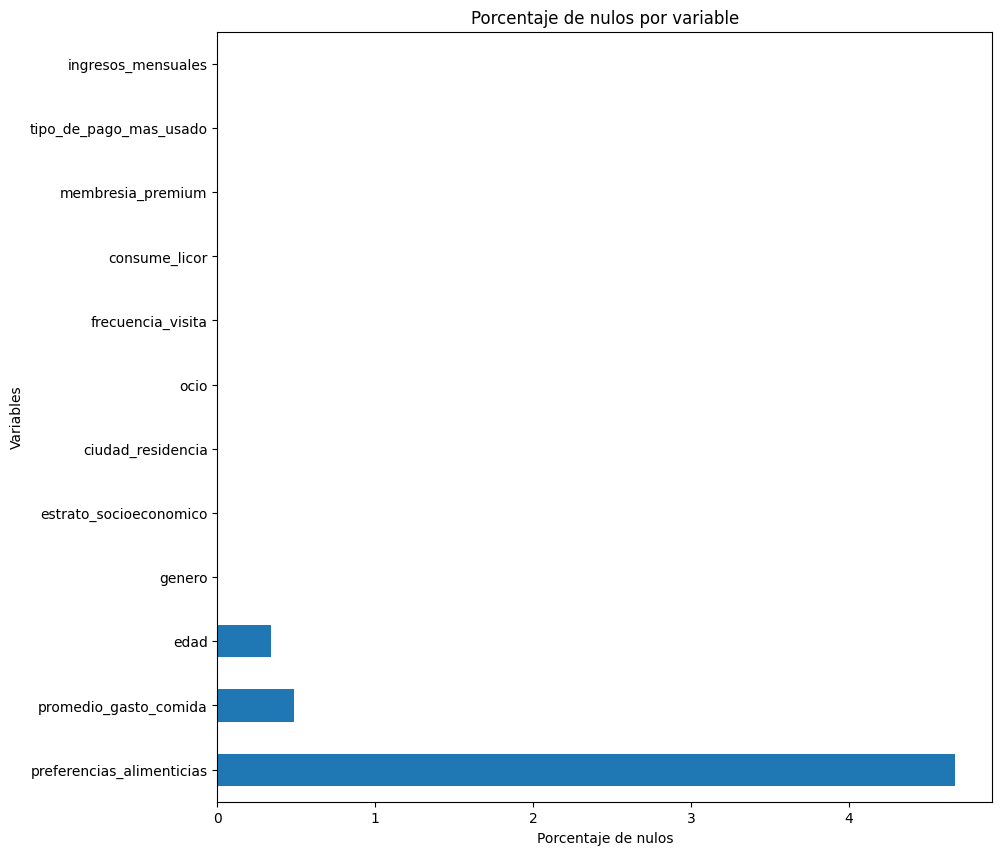

In [ ]:
#Graficación del porcentaje de nulos por variable
(df.isnull().mean()*100).sort_values(ascending=False).plot(kind='barh', figsize=(10,10))
plt.title('Porcentaje de nulos por variable')
plt.xlabel('Porcentaje de nulos')
plt.ylabel('Variables')
plt.show()
#

Estadisticas Generales

In [ ]:
#Estadisticas descriptivas
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
edad,29899.0,NaN,NaN,NaN,49.665006,23.83955,-5.0,33.0,49.0,65.0,300.0
genero,30000,2,Femenino,15044,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ciudad_residencia,30000,10,Chicago,5384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estrato_socioeconomico,30000,4,Medio,9325,NaN,NaN,NaN,NaN,NaN,NaN,NaN
frecuencia_visita,30000.0,NaN,NaN,NaN,3.896133,2.741532,-3.0,2.0,4.0,5.0,10.0
promedio_gasto_comida,29855.0,NaN,NaN,NaN,32.603452,26.402601,0.0,13.29,25.51,44.4,149.97
ocio,30000,2,No,15094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
consume_licor,30000,2,Sí,18483,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preferencias_alimenticias,28597,6,Carnes,7916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
membresia_premium,30000,2,No,17155,NaN,NaN,NaN,NaN,NaN,NaN,NaN


25%: cuartil 1

* En edad hay posibles atipicos con números negativos y máximos 300. En edad hay una desviación estandar muy alta. Coeficiente de variación es casi del 50%. De esos 30k datos, 15k tienen 49 años o más, 7500 tienen 65 o más. 75% tienen 33 o más.
* En frecuencia posibles atipicos con número negativo. 75% de las personas van 2 o más veces a la semana al restaurante. 50% de las personas van 4 o más veces a la semana al restaurante.
* La mayoria no usan membresia premium
* La mayoria usa efectivo (puede relacionarse más con la edad)
* Desviación estandar muy alta en ingresos, pero es normal.


* EDA UNIVARIADO

Tomar cada variable y hacerle un analisis en 2 sentidos: análisis para los numérciso y para los categóricos

Para los numéricos se habla de distribuciones para identificar sesgos/atípicos, y para estas es clave hacer HISTOGRAMAS Y BOXPLOT

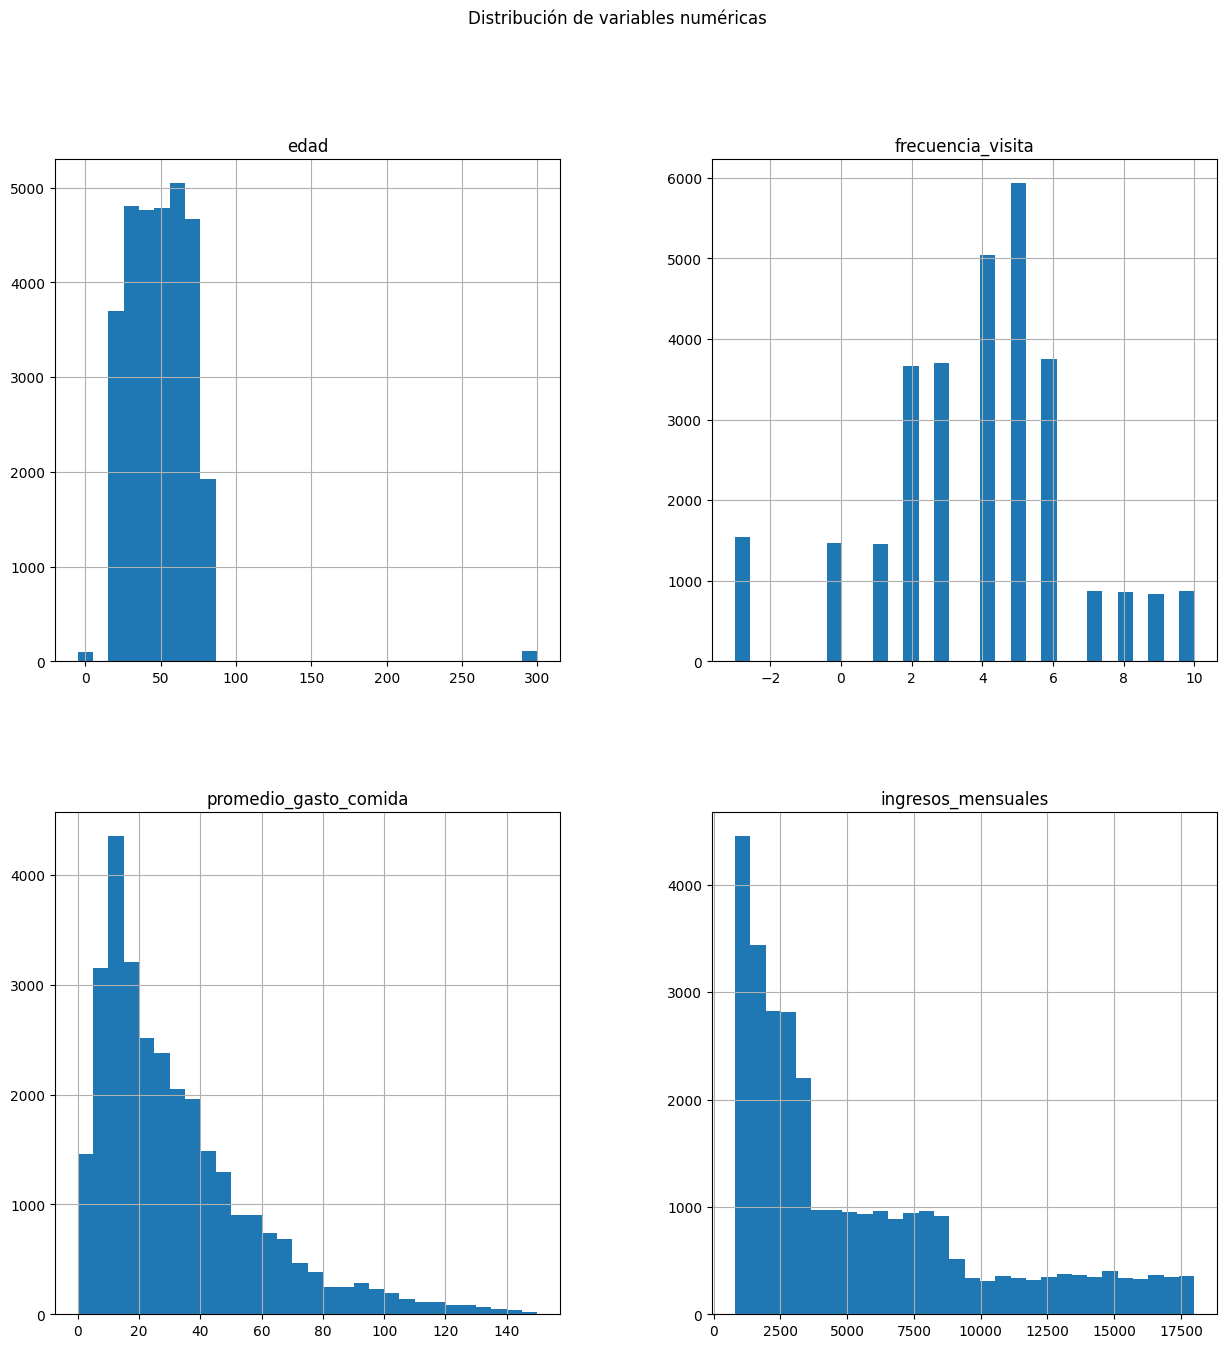

In [ ]:
#distribución de variables numéricas
df.select_dtypes(include=np.number).hist(figsize=(15,15), bins=30)
plt.suptitle('Distribución de variables numéricas')
plt.show()

* La gráfica de ingresos es muy usual, ingresos altos menos personas

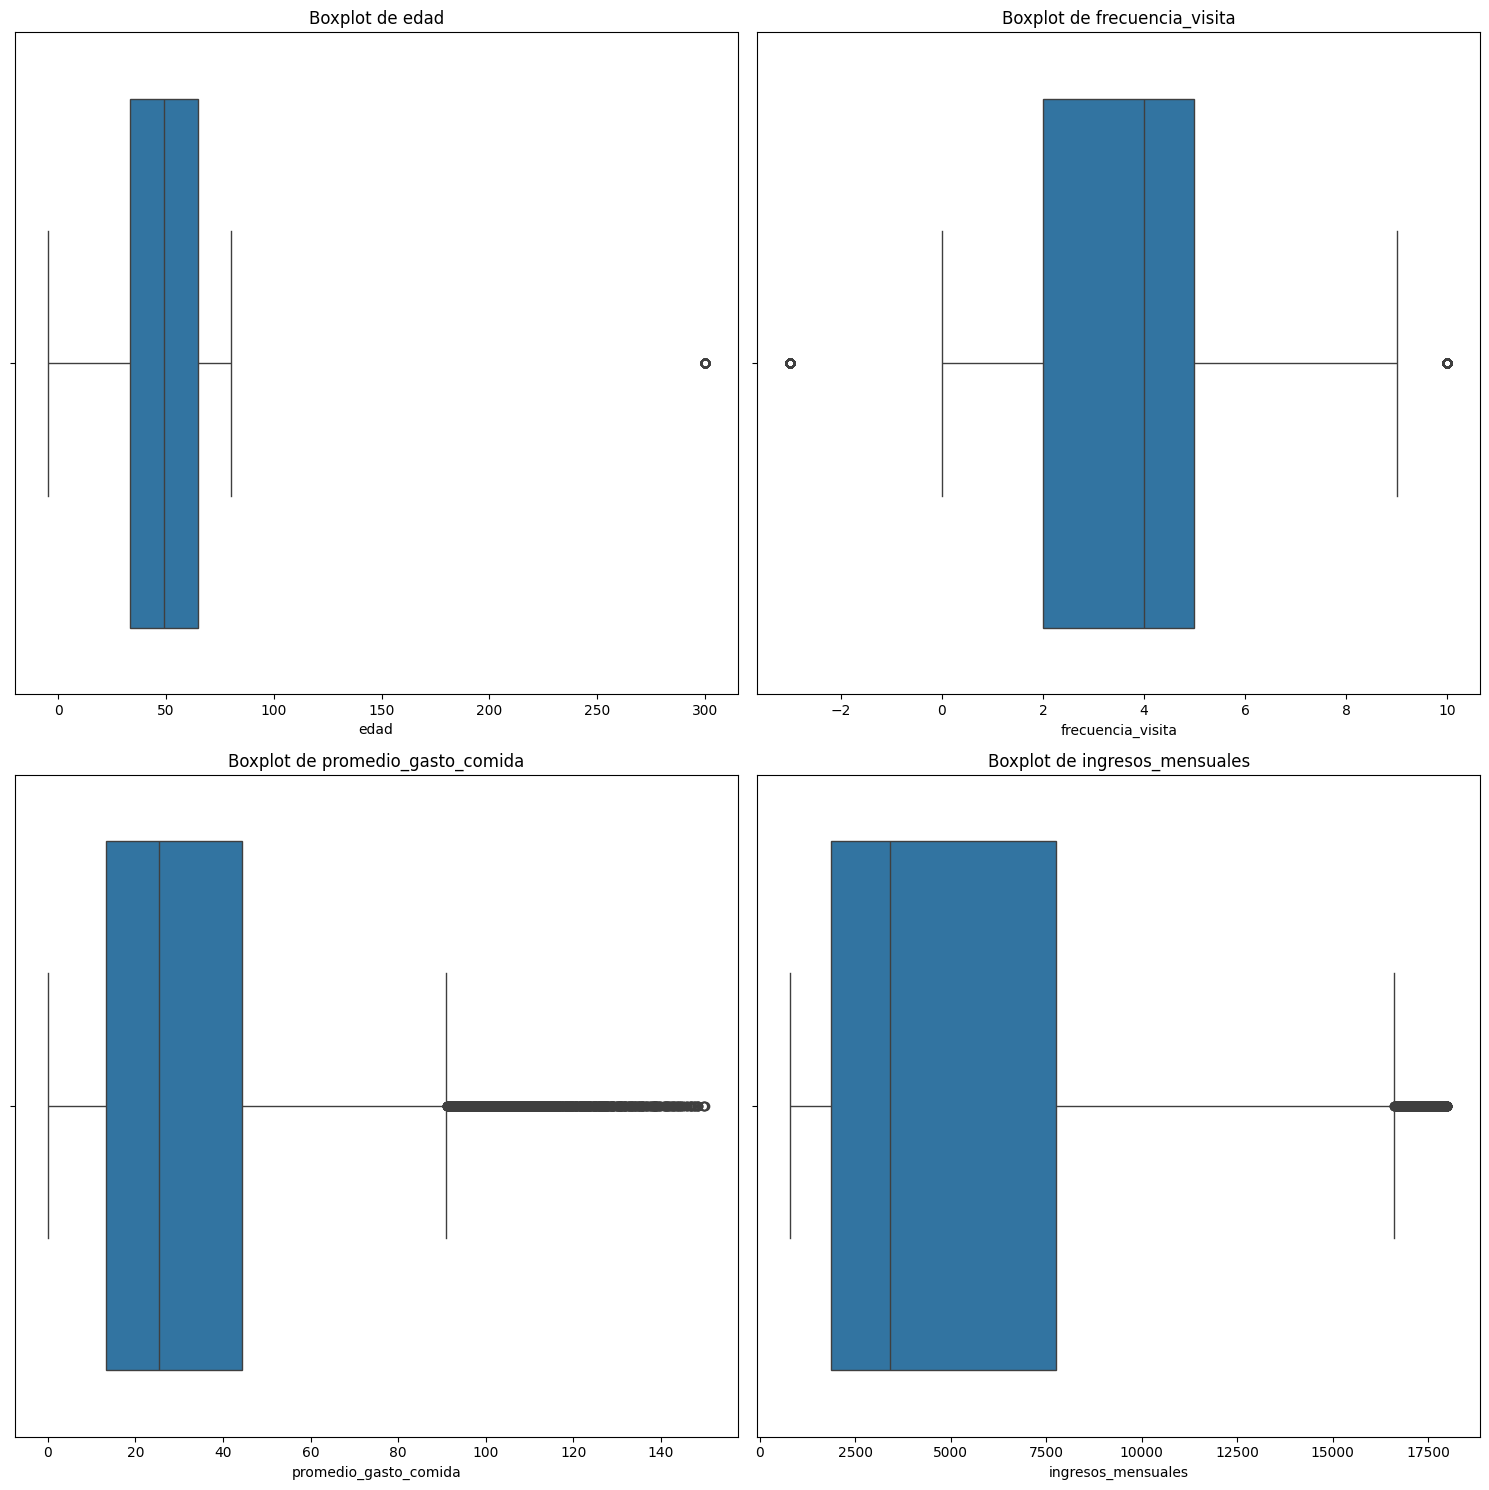

In [ ]:
#boxplots para detectar outliers
num_cols = ['edad', 'frecuencia_visita', 'promedio_gasto_comida', 'ingresos_mensuales']
plt.figure(figsize=(15,15))
for i,col in enumerate(num_cols):
  plt.subplot(2,2,i+1)
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

Entre Q3 Y Q1 hay distancia intercuartilica, que es a partir de la cual se calcula el limite inferior y superior (los bigotes) que dicen a partir de que punto voy a considerar estadisticamente un atipico

Hay que tener cuidado porque hay que verlo a la luz del negocio, por ej hay gente que puede tener mucho dinero que estadísticamente sean atipicos, y se pueden tomar decisiones con esto: se generan 2 segmentos.

Con los CATEGÓRICOS

Vamos a hacer tablas (más que todo de frecuencia) dibujar columnas

In [ ]:
#columnas y sus respectivos valores
cat_cols = df.select_dtypes(include= 'object').columns
for col in cat_cols:
  print(f'Columna: {col}')
  print(df[col].value_counts(dropna=False))

Columna: genero
genero
Femenino     15044
Masculino    14956
Name: count, dtype: int64
Columna: ciudad_residencia
ciudad_residencia
Chicago      5384
NYC          4769
Miami        3186
San Diego    3075
Dallas       2602
Boston       2547
Denver       2523
Houston      2212
Seattle      2191
Phoenix      1511
Name: count, dtype: int64
Columna: estrato_socioeconomico
estrato_socioeconomico
Medio       9325
Alto        9038
Bajo        6161
Muy Alto    5476
Name: count, dtype: int64
Columna: ocio
ocio
No    15094
Sí    14906
Name: count, dtype: int64
Columna: consume_licor
consume_licor
Sí    18483
No    11517
Name: count, dtype: int64
Columna: preferencias_alimenticias
preferencias_alimenticias
Carnes         7916
Vegetariano    6580
Mariscos       5212
Vegano         3267
Pescado        2983
Otro           2639
NaN            1403
Name: count, dtype: int64
Columna: membresia_premium
membresia_premium
No    17155
Sí    12845
Name: count, dtype: int64
Columna: tipo_de_pago_mas_usado
tip

# ELIMINACIÓN DE OUTLIERS

para tener un mejor analisis  

In [ ]:
#edades negativas y absurdas
df['edad'] = df['edad'].apply(lambda x: x if(x is not None and 18 <= x <= 80) else np.nan)

#frecuencia de visita absurda
df['frecuencia_visita'] = df['frecuencia_visita'].apply(lambda x: x if(x is not None and 0 < x <= 15) else np.nan)

In [ ]:
#se puede volver a graficar

Imputacion de dtaos nulos

Con KNN ya que permite estimar los datos ausentes considerando la similitud entre ibservaciones, lo cual resulta mas contextual y preciso.

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

columnas_numericas = ['edad', 'frecuencia_visita', 'promedio_gasto_comida' , 'ingresos_mensuales']

df_numerico = df[columnas_numericas]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numerico)

imputer = KNNImputer(n_neighbors=5)
df_imputado_scaled = imputer.fit_transform(df_scaled)

df_imputado = scaler.inverse_transform(df_imputado_scaled)
df[columnas_numericas] = pd.DataFrame(df_imputado, columns=columnas_numericas)

In [ ]:
df['preferencias_alimenticias'].value_counts()

,count
preferencias_alimenticias,
Carnes,7916
Vegetariano,6580
Mariscos,5212
Vegano,3267
Pescado,2983
Otro,2639


In [ ]:
#Imputar preferencias alimenticias como Otro
df['preferencias_alimenticias'] = df['preferencias_alimenticias'].fillna('Otro')

Como se imputo con KNN se pasaron todas como float, asi que:

In [ ]:
df = df.astype({'edad': 'int', 'frecuencia_visita': 'int', 'promedio_gasto_comida': 'float', 'ingresos_mensuales': 'float'})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   edad                       30000 non-null  int64  
 1   genero                     30000 non-null  object 
 2   ciudad_residencia          30000 non-null  object 
 3   estrato_socioeconomico     30000 non-null  object 
 4   frecuencia_visita          30000 non-null  int64  
 5   promedio_gasto_comida      30000 non-null  float64
 6   ocio                       30000 non-null  object 
 7   consume_licor              30000 non-null  object 
 8   preferencias_alimenticias  30000 non-null  object 
 9   membresia_premium          30000 non-null  object 
 10  tipo_de_pago_mas_usado     30000 non-null  object 
 11  ingresos_mensuales         30000 non-null  float64
dtypes: float64(2), int64(2), object(8)
memory usage: 2.7+ MB


Que preguntas se pueden responder y que datos sacar de este dataset

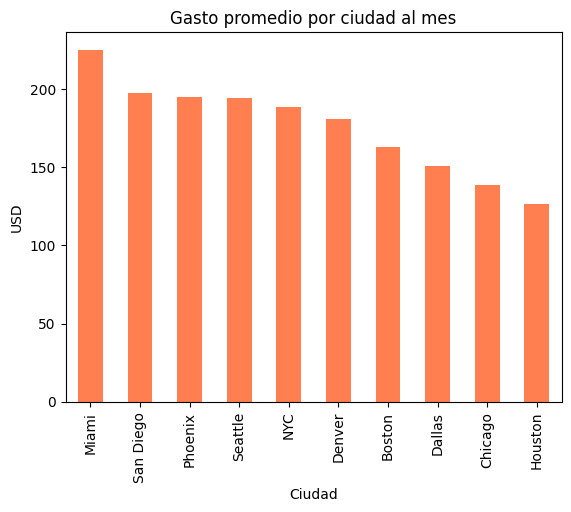

In [ ]:
#Gasto promedio por ciudad al mes
df['promedio_gasto_total_mes'] = df['frecuencia_visita'] * df['promedio_gasto_comida']
city_gasto = df.groupby('ciudad_residencia')['promedio_gasto_total_mes'].mean().sort_values(ascending=False)

city_gasto.plot(kind='bar', color = 'coral')
plt.title('Gasto promedio por ciudad al mes')
plt.ylabel('USD')
plt.xlabel('Ciudad')
plt.show()

MiAMI es donde más se gasta pero no es la de mayor frecuencia, es Chicago

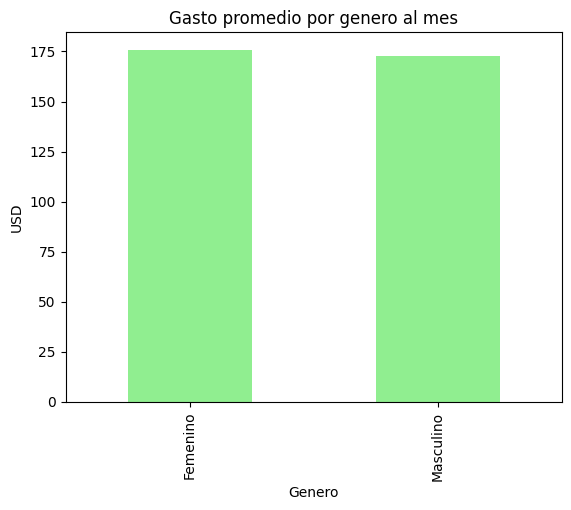

In [ ]:
#Gasto promedio genero al mes

genero_gasto = df.groupby('genero')['promedio_gasto_total_mes'].mean().sort_values(ascending=False)
genero_gasto.plot(kind='bar', color = 'lightgreen')
plt.title('Gasto promedio por genero al mes')
plt.ylabel('USD')
plt.xlabel('Genero')
plt.show()

Text(0.5, 0, 'Estrato socioeconomico')

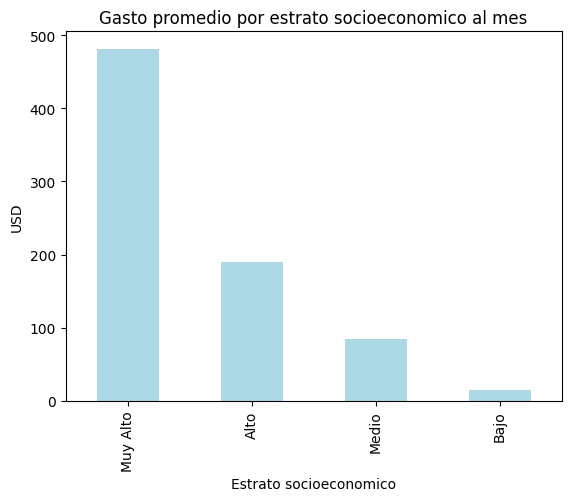

In [ ]:
#gasto promedio por estrato socioeconomico al mes

estrato_gasto = df.groupby('estrato_socioeconomico')['promedio_gasto_total_mes'].mean().sort_values(ascending=False)
estrato_gasto.plot(kind='bar', color = 'lightblue')
plt.title('Gasto promedio por estrato socioeconomico al mes')
plt.ylabel('USD')
plt.xlabel('Estrato socioeconomico')

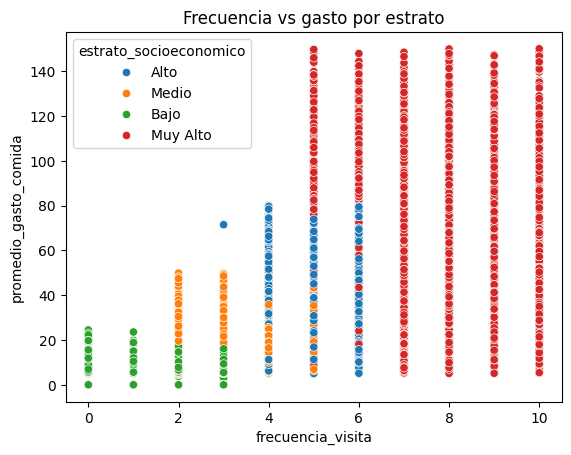

In [ ]:
#segmentos por frecuencia y gasto
sns.scatterplot(data=df, x='frecuencia_visita', y='promedio_gasto_comida', hue= 'estrato_socioeconomico')
plt.title('Frecuencia vs gasto por estrato')
plt.show()

Variables clave: estrato, gasto, frecuencia,

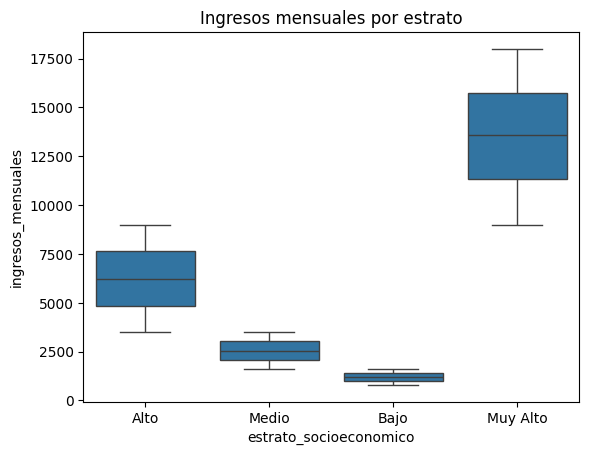

In [ ]:
# boxplot de ingresos mensuales por estrato
sns.boxplot(data=df, x='estrato_socioeconomico', y='ingresos_mensuales')
plt.title('Ingresos mensuales por estrato')
plt.show()

aca empezamos a ver variables redundantes:

* hay una forma de verlo con numericas: matriz de correlacion
* categoricas: más complejo, se puede ver por ej correlacion entre estrato e ingreso en el boxplot. Nos quedamos con ingresos porque es la numerica y da mas info que la categorica

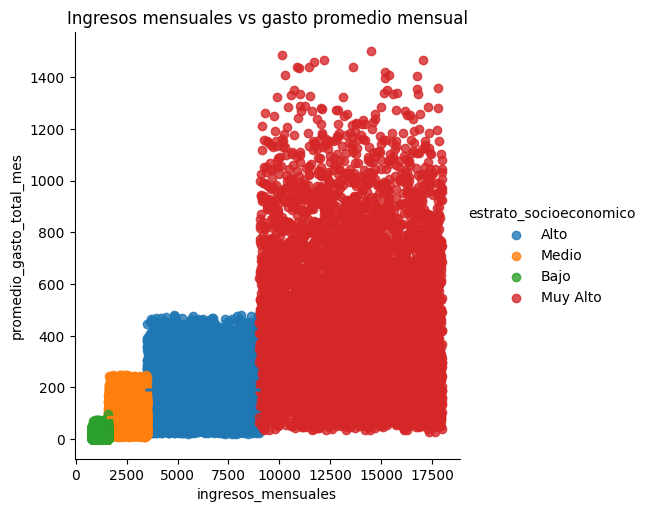

In [ ]:
#grafico de dispersion de ingresos mensuales vs gasto promedio mensual
df['promedio_gasto_total_mes'] = df['frecuencia_visita'] * df['promedio_gasto_comida']
sns.lmplot(data=df, x='ingresos_mensuales', y='promedio_gasto_total_mes', hue='estrato_socioeconomico')
plt.title('Ingresos mensuales vs gasto promedio mensual')
plt.show()

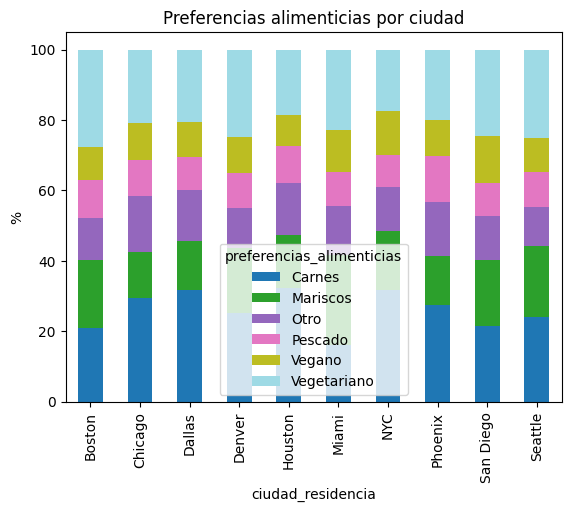

In [ ]:
#preferencias alimenticias por ciudad
pref_ciudad = pd.crosstab(df['ciudad_residencia'], df['preferencias_alimenticias'], normalize= 'index')*100
pref_ciudad.plot(kind='bar', stacked=True, colormap= 'tab20')
plt.title('Preferencias alimenticias por ciudad')
plt.ylabel('%')
plt.show()

In [ ]:
#perfil del cliente de alto gasto

#top 10% en gasto
threshold = df['promedio_gasto_comida'].quantile(0.9) #valor q gasta el 10% más top
elite = df[df['promedio_gasto_comida'] >= threshold]

elite.describe(include='all')

,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,tipo_de_pago_mas_usado,ingresos_mensuales,promedio_gasto_total_mes
count,3001.000000,3001,3001,3001,3001.000000,3001.000000,3001,3001,3001,3001,3001,3001.000000,3001.000000
unique,NaN,2,10,2,NaN,NaN,2,2,6,2,4,NaN,NaN
top,NaN,Femenino,NYC,Muy Alto,NaN,NaN,Sí,Sí,Carnes,Sí,Efectivo,NaN,NaN
freq,NaN,1563,645,2492,NaN,NaN,1530,1863,792,2726,1194,NaN,NaN
mean,48.648784,NaN,NaN,NaN,7.054982,92.346421,NaN,NaN,NaN,NaN,NaN,12233.500500,659.495587
std,18.196848,NaN,NaN,NaN,1.836294,19.624987,NaN,NaN,NaN,NaN,NaN,3652.699569,241.440701
min,18.000000,NaN,NaN,NaN,3.000000,68.150000,NaN,NaN,NaN,NaN,NaN,3501.000000,214.350000
25%,33.000000,NaN,NaN,NaN,5.000000,75.750000,NaN,NaN,NaN,NaN,NaN,9883.000000,463.740000
50%,49.000000,NaN,NaN,NaN,7.000000,88.300000,NaN,NaN,NaN,NaN,NaN,12692.000000,634.200000
75%,64.000000,NaN,NaN,NaN,9.000000,104.060000,NaN,NaN,NaN,NaN,NaN,15138.000000,814.770000


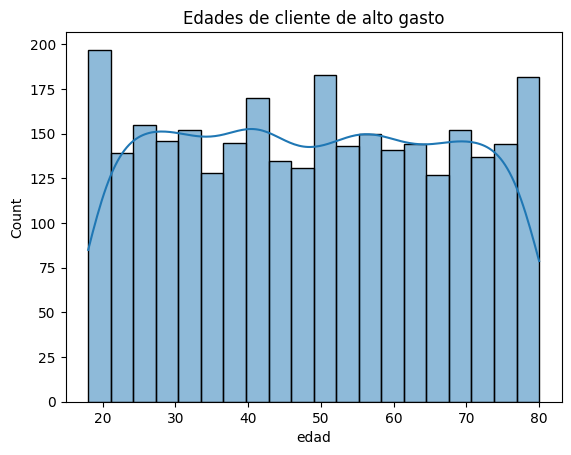

In [ ]:
#histograma de edades de cliente de alto gasto
sns.histplot(elite['edad'], bins=20, kde=True)
plt.title('Edades de cliente de alto gasto')
plt.show()

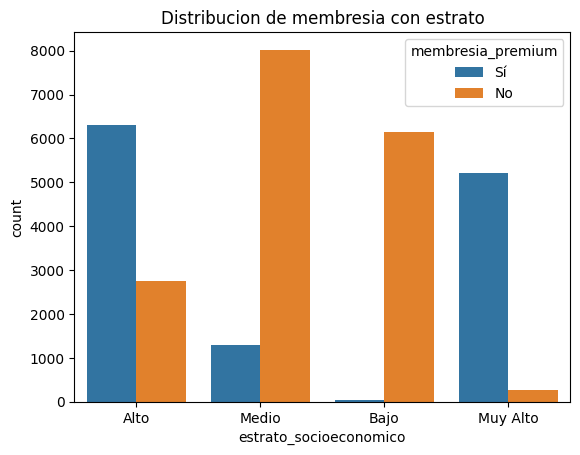

In [ ]:
#distribucion de membresia con estrato
sns.countplot(data=df, x='estrato_socioeconomico', hue='membresia_premium')
plt.title('Distribucion de membresia con estrato')
plt.show()

oportunidad en el medio que todavia no tienen membresía

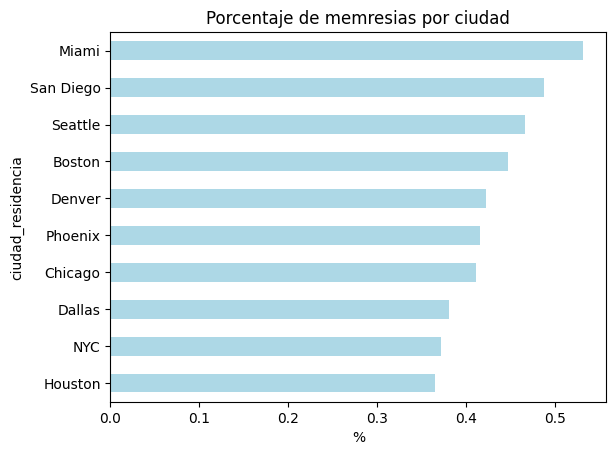

In [ ]:
#porcentaje de memresias por ciudad
membresia_ciudad = df.groupby('ciudad_residencia')['membresia_premium'].value_counts(normalize=True).unstack()
membresia_ciudad['Sí'].sort_values().plot(kind='barh', color = 'lightblue')
plt.title('Porcentaje de memresias por ciudad')
plt.xlabel('%')
plt.show()

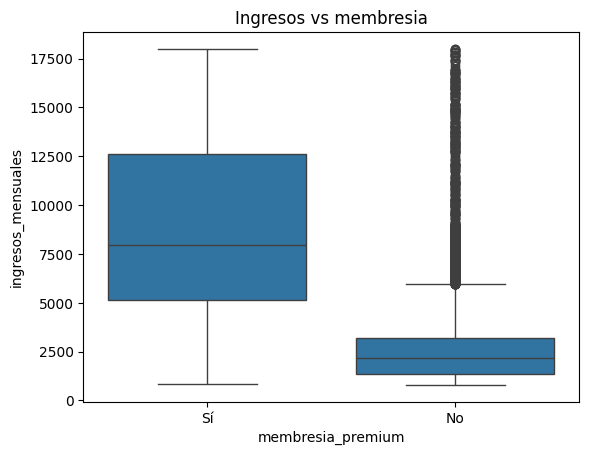

In [ ]:
#ingresos vs membresia
sns.boxplot(data=df, x='membresia_premium', y='ingresos_mensuales')
plt.title('Ingresos vs membresia')
plt.show()

Si bien hay personas con ingresos altos, no tienen membresia, pero los que tienen membresia tienen ingresos altos.

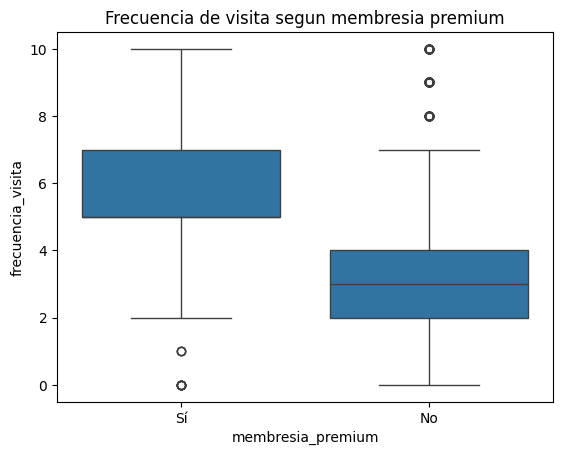

In [ ]:
#frecuencua de visita segun membresia premium
sns.boxplot(data=df, x='membresia_premium', y='frecuencia_visita')
plt.title('Frecuencia de visita segun membresia premium')
plt.show()

Es atipico que haya gente que vaya mucho y tenga membresia, y es atipico que haya gente con membresia que casi no vaya

In [ ]:
#crosstab preferecnias alimenticias
#como hay tantas var categoricas se nos acaban las opciones
pd.crosstab(df['preferencias_alimenticias'], df['membresia_premium'], normalize= 'index')*100

membresia_premium,No,Sí
preferencias_alimenticias,,
Carnes,59.183931,40.816069
Mariscos,55.890253,44.109747
Otro,57.644730,42.355270
Pescado,57.626550,42.373450
Vegano,57.055403,42.944597
Vegetariano,55.379939,44.620061


porcentaje de personas de membresia de acuerdo a sus preferencias alimenticias

se puede ver que las preferencias alimenticias no influyen en la membresia

/tmp/ipython-input-1868337822.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  alcohol_por_edad = df.groupby('grupo_edad')['consume_licor'].value_counts(normalize=True).unstack()


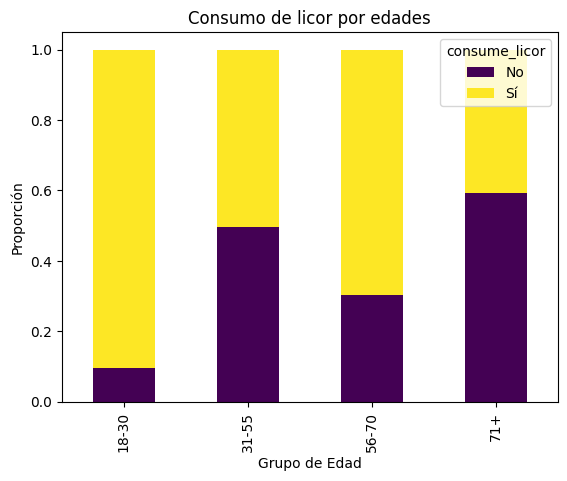

In [ ]:
#consumo de licor por edades

df['grupo_edad'] = pd.cut(df['edad'], bins=[17,30,55,70,100], labels=['18-30', '31-55', '56-70', '71+'])

alcohol_por_edad = df.groupby('grupo_edad')['consume_licor'].value_counts(normalize=True).unstack()
alcohol_por_edad.plot(kind='bar', stacked=True, colormap= 'viridis')
plt.title('Consumo de licor por edades')
plt.ylabel('Proporción')
plt.xlabel('Grupo de Edad')
plt.show()
